In [1]:
import h5py
import numpy as np

In [2]:
reference_mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\reference_packet.mat'

In [3]:
with h5py.File(reference_mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [4]:
reference_packet = reference_packet[0, :]

In [5]:
reference_packet

array([ 0.01367188,  0.0078125 ,  0.03789063, ...,  0.01976563,
        0.01117187, -0.0346875 ], shape=(250000,))

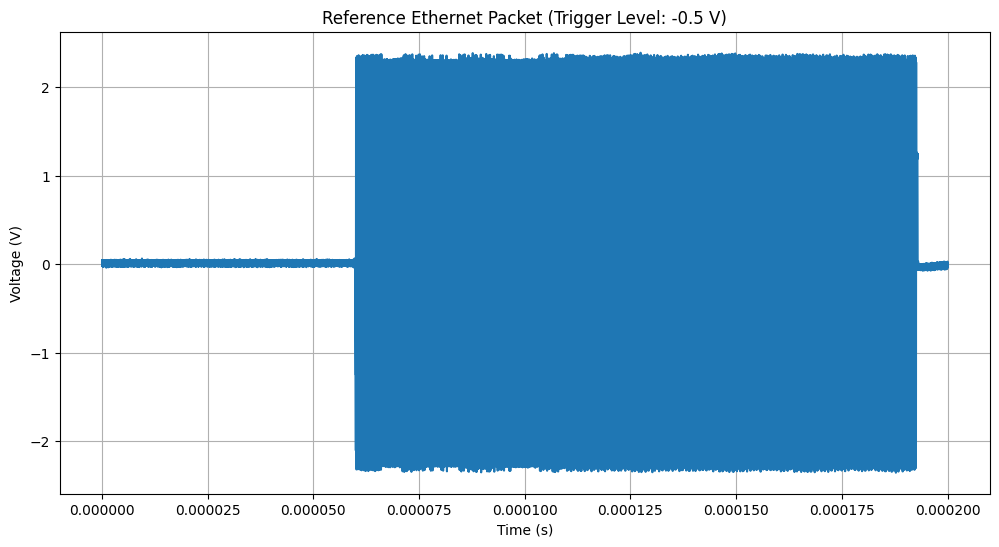

In [6]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [7]:
signal = reference_packet

In [8]:
def extract_packet(signal, threshold=0.2):
    # 1. Create boolean mask
    active = np.abs(signal) > threshold
    
    # 2. Find indices where active is True
    indices = np.where(active)[0]
    
    # 3. Handle case where no signal exceeds threshold
    if indices.size == 0:
        return np.array([]) # or return None
        
    # 4. Get start and end (add 1 to end for slicing)
    start = indices[0]
    end = indices[-1] + 1
    
    return signal[start:end]

# Usage
packet = extract_packet(signal, 0.1)

In [9]:
# import numpy as np

# # signal = your waveform
# threshold = 0.2

# active = np.abs(signal) > threshold

# start = np.argmax(active)
# end = len(signal) - np.argmax(active[::-1])

# packet = signal[start:end]

In [10]:
samples_per_bit = int(sample_rate / 10e6)  # 10Mbps
samples_per_bit

125

In [11]:
# print("Packet length (samples):", len(packet))
# print("Packet duration (s):", len(packet) / sample_rate)

# print("Packet duration (bits):", len(packet) / samples_per_bit)
# print("Packet duration (bytes):", len(packet) / (samples_per_bit * 8))
# print("Packet duration (frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Packet duration (Ethernet frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Start index:", start)
# print("End index:", end)

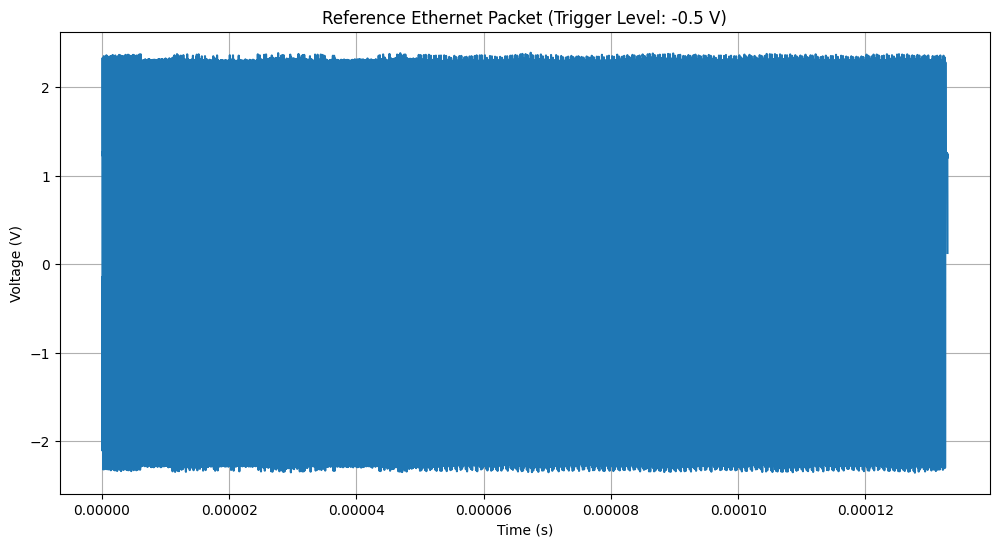

In [12]:
time_axis = np.arange(len(packet)) / sample_rate
plt.figure(figsize=(12,6))
plt.plot(time_axis, packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [13]:
packet[:200]

array([-0.14835938, -0.1609375 , -0.21046875, -0.24359375, -0.34007813,
       -0.35617188, -0.38601563, -0.44820313, -0.51554687, -0.54609375,
       -0.58796875, -0.63539062, -0.71445313, -0.74914063, -0.78539063,
       -0.83      , -0.89554687, -0.91664062, -0.9690625 , -1.03125   ,
       -1.07554688, -1.09617188, -1.16734375, -1.25046875, -1.3384375 ,
       -1.4096875 , -1.46867188, -1.53296875, -1.62921875, -1.6834375 ,
       -1.74398438, -1.80882813, -1.89015625, -1.91882813, -1.94640625,
       -1.99453125, -2.038125  , -2.0534375 , -2.0478125 , -2.0915625 ,
       -2.10789063, -2.10085938, -2.07554688, -2.0859375 , -2.08734375,
       -2.103125  , -2.07242187, -2.08914063, -2.058125  , -2.0321875 ,
       -1.9909375 , -1.9621875 , -1.93757813, -1.86304687, -1.79789062,
       -1.726875  , -1.65304688, -1.571875  , -1.4728125 , -1.37953125,
       -1.25421875, -1.11617188, -0.9721875 , -0.82101563, -0.68523438,
       -0.54671875, -0.40507813, -0.28046875, -0.17023437, -0.02

In [14]:
packet[:67+125]

array([-0.14835938, -0.1609375 , -0.21046875, -0.24359375, -0.34007813,
       -0.35617188, -0.38601563, -0.44820313, -0.51554687, -0.54609375,
       -0.58796875, -0.63539062, -0.71445313, -0.74914063, -0.78539063,
       -0.83      , -0.89554687, -0.91664062, -0.9690625 , -1.03125   ,
       -1.07554688, -1.09617188, -1.16734375, -1.25046875, -1.3384375 ,
       -1.4096875 , -1.46867188, -1.53296875, -1.62921875, -1.6834375 ,
       -1.74398438, -1.80882813, -1.89015625, -1.91882813, -1.94640625,
       -1.99453125, -2.038125  , -2.0534375 , -2.0478125 , -2.0915625 ,
       -2.10789063, -2.10085938, -2.07554688, -2.0859375 , -2.08734375,
       -2.103125  , -2.07242187, -2.08914063, -2.058125  , -2.0321875 ,
       -1.9909375 , -1.9621875 , -1.93757813, -1.86304687, -1.79789062,
       -1.726875  , -1.65304688, -1.571875  , -1.4728125 , -1.37953125,
       -1.25421875, -1.11617188, -0.9721875 , -0.82101563, -0.68523438,
       -0.54671875, -0.40507813, -0.28046875, -0.17023437, -0.02

In [15]:
packet = packet - np.mean(packet)

In [16]:
digital = packet > 0

In [17]:
digital[:100]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [18]:
digital = digital.astype(int)

In [19]:
edges = np.where(np.diff(digital) != 0)[0]

In [20]:
edges

array([    69,    191,    316, ..., 165566, 165631, 165694], shape=(2071,))

In [21]:
edge_distances = np.diff(edges)

In [22]:
edge_distances

array([122, 125, 125, ..., 125,  65,  63], shape=(2070,))

In [23]:
bit_distance = 125
tolerance = 20
relevant_edges = [edges[0]]  # Start with the first edge

In [24]:
i = 0
while i < len(edge_distances):
    if abs(edge_distances[i] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+1])  # Store the index of the edge
        i += 1  # Move to next edge
    elif i+1 < len(edge_distances) and abs(edge_distances[i] + edge_distances[i+1] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+2])  # Store the index of the edge
        i += 2  # Move to the next pair of edges
    else:
        print(f"Unexpected edge distance at index {i}: {edge_distances[i]} samples")
        i += 1  # Move to next edge

In [25]:
relevant_edges[-3:]

[np.int64(165441), np.int64(165566), np.int64(165694)]

In [26]:
bits = []

for e in relevant_edges:
    if digital[e] == 0 and digital[e+1] == 1:
        bits.append(1)     # rising edge
    elif digital[e] == 1 and digital[e+1] == 0:
        bits.append(0)     # falling edge
    else:
        raise ValueError(f"Unexpected edge at index {e}: digital[{e}]={digital[e]}, digital[{e+1}]={digital[e+1]}")

In [27]:
len(bits)

1326

In [28]:
bits

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,


In [29]:
bits[:64]

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1]

In [30]:
bitstring = ''.join(map(str,bits))

idx = bitstring.find("10101010101010101010101010101010101010101010101010101011")

print("packet start bit:", idx)

packet start bit: 6


In [31]:
def find_sfd(bits):

    pattern = [1,0]*7 + [1,1]  # 10101011
    
    for i in range(len(bits)-len(pattern)):
        if bits[i:i+len(pattern)] == pattern:
            return i + len(pattern)

    return None

In [32]:
payload_start_bit = find_sfd(bits)
print("payload start bit:", payload_start_bit)

payload start bit: 62


In [33]:
start = 62

dest_bits = bits[start : start+48]
src_bits  = bits[start+48 : start+96]
type_bits = bits[start+96 : start+112]

payload_bits = bits[494 : -32]
crc_bits     = bits[-32:]

In [34]:
def bits_to_bytes(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte = (byte << 1) | bits[i+j]
        bytes_out.append(byte)
        
    return bytes_out

In [45]:
def bits_to_bytes_lsb(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte |= (bits[i + j] << j)  # LSB first
        bytes_out.append(byte)
    
    return bytes_out

In [46]:
dest_mac = bits_to_bytes(dest_bits)
src_mac  = bits_to_bytes(src_bits)
eth_type = bits_to_bytes(type_bits)
payload  = bits_to_bytes_lsb(payload_bits)
crc      = bits_to_bytes(crc_bits)

In [47]:
payload_bits

[0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,


In [48]:
dest_mac

[255, 255, 255, 255, 255, 255]

In [49]:
len(payload)

100

In [50]:
payload

[88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88,
 88]

In [40]:
samples_per_bit = int(sample_rate / 100e6)  # 100 Mbps
num_bits = len(digital) // samples_per_bit

In [41]:
payload

[26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26]

In [42]:
def decode_manchester(bits, samples_per_bit):

    decoded = []

    for i in range(0, len(bits)-samples_per_bit, samples_per_bit):

        first = bits[i + samples_per_bit//4]
        second = bits[i + 3*samples_per_bit//4]

        if first == 0 and second == 1:
            decoded.append(1)
        elif first == 1 and second == 0:
            decoded.append(0)

    return np.array(decoded)